In [61]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()

# Gör så att Python hittar src/
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import load_config

# Läs config
CONFIG_PATH = PROJECT_ROOT / "config.toml"
config = load_config(CONFIG_PATH, PROJECT_ROOT)


# Luftdata / PM2.5
air_df = pd.read_csv(
    config.raw_dir / "train_Malmö Dalaplan.csv"
)

# Väderdata
weather_df = pd.read_csv(
    config.raw_dir / "train_Malmö A.csv"
)

# Sammanfogad data
merged_df = pd.read_csv(
    config.merged_dir / "train_merged.csv"
)

## 1. Kontroll av struktur och datatyper

**Observation:**  
Samtliga mätvariabler är numeriska (`float64`). Tidsvariabeln `tid` är däremot inläst som `str` och behöver konverteras till `datetime` innan vidare analys av tidsserien.

Eftersom tidsstämplarna innehåller både svensk sommartid (CEST) och vintertid (CET) konverteras `tid` i denna notebook till timezone-aware `datetime` (`Europe/Stockholm`). Detta görs här för att möjliggöra korrekt analys av tidsserien. I den slutliga pipelinen bör konverteringen i stället hanteras vid inläsning av data.

In [62]:
print("LUFTDATA")
air_df.info()

print("\nVÄDERDATA")
weather_df.info()

print("\nMERGED DATA")
merged_df.info()

LUFTDATA
<class 'pandas.DataFrame'>
RangeIndex: 22855 entries, 0 to 22854
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tid     22855 non-null  str    
 1   pm25    22702 non-null  float64
dtypes: float64(1), str(1)
memory usage: 357.2 KB

VÄDERDATA
<class 'pandas.DataFrame'>
RangeIndex: 22290 entries, 0 to 22289
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   tid                    22290 non-null  str    
 1   Lufttemperatur         22289 non-null  float64
 2   Vindriktning           22253 non-null  float64
 3   Vindhastighet          22253 non-null  float64
 4   Relativ luftfuktighet  22255 non-null  float64
 5   Nederbördsmängd        21756 non-null  float64
dtypes: float64(5), str(1)
memory usage: 1.0 MB

MERGED DATA
<class 'pandas.DataFrame'>
RangeIndex: 22857 entries, 0 to 22856
Data columns (total 7 columns):
 #   Column   

In [63]:
for df in [air_df, weather_df, merged_df]:
    df["tid"] = (pd.to_datetime(df["tid"], utc=True)
    .dt.tz_convert("Europe/Stockholm")
    )

print(air_df["tid"].dtype)
print(weather_df["tid"].dtype)
print(merged_df["tid"].dtype)

datetime64[us, Europe/Stockholm]
datetime64[us, Europe/Stockholm]
datetime64[us, Europe/Stockholm]


## 2. Kontroll av antal observationer och tidsintervall

**Förväntat antal observationer:** 22 825 timmar

**Observation:**
- PM2.5-data innehåller 22 855 observationer, alltså fler rader än det
  förväntade antalet timmar. Dessutom sträcker sig tidsintervallet till
  2026-01-01 00:00, trots att träningsperioden slutar 2025-12-31.
- Väderdata innehåller 22 290 observationer och följer det förväntade
  tidsintervallet 2023-05-26–2025-12-31.
- Merged data innehåller 22 857 observationer och sträcker sig också till
  2026-01-01 00:00.

Data har hämtats om med nuvarande konfiguration och avvikelsen
kvarstår. Filtreringen av PM2.5-data behöver därför kontrolleras,
framför allt hanteringen av start-/sluttid och tidszon.


In [64]:
config.train_start
config.train_slut

expected_timestamps = pd.date_range(
    start=config.train_start,
    end=f"{config.train_slut} 23:00:00",
    freq="h",
    tz="Europe/Stockholm"
)

expected_count = len(expected_timestamps)

print("Förväntat antal timmar:", expected_count)

print("Luftdata:", air_df.shape)
print("Väderdata:", weather_df.shape)
print("Merged:", merged_df.shape)

print("\nLUFTDATA")
print("Första:", air_df["tid"].min())
print("Sista:", air_df["tid"].max())

print("\nVÄDERDATA")
print("Första:", weather_df["tid"].min())
print("Sista:", weather_df["tid"].max())

print("\nMERGED")
print("Första:", merged_df["tid"].min())
print("Sista:", merged_df["tid"].max())

Förväntat antal timmar: 22825
Luftdata: (22855, 2)
Väderdata: (22290, 6)
Merged: (22857, 7)

LUFTDATA
Första: 2023-05-26 02:00:00+02:00
Sista: 2026-01-01 00:00:00+01:00

VÄDERDATA
Första: 2023-05-26 00:00:00+02:00
Sista: 2025-12-31 23:00:00+01:00

MERGED
Första: 2023-05-26 00:00:00+02:00
Sista: 2026-01-01 00:00:00+01:00


## 3. Kontroll av saknade värden

**Observation:**  
Merged data har en högre andel saknade värden än respektive ursprungsdata. 
Detta tyder på att dataseten delvis saknar observationer för olika tidsstämplar, 
vilket skapar ytterligare NaN-värden vid merge.

In [65]:
def missing_values(df):
    return pd.DataFrame({
        "Antal saknade": df.isna().sum(),
        "Andel saknade (%)": (df.isna().mean() * 100).round(2)
    })

print("\nLUFTDATA")
print(missing_values(air_df))

print("\nVÄDERDATA")
print(missing_values(weather_df))

print("\nMERGED DATA")
print(missing_values(merged_df))


LUFTDATA
      Antal saknade  Andel saknade (%)
tid               0               0.00
pm25            153               0.67

VÄDERDATA
                       Antal saknade  Andel saknade (%)
tid                                0               0.00
Lufttemperatur                     1               0.00
Vindriktning                      37               0.17
Vindhastighet                     37               0.17
Relativ luftfuktighet             35               0.16
Nederbördsmängd                  534               2.40

MERGED DATA
                       Antal saknade  Andel saknade (%)
tid                                0               0.00
pm25                             155               0.68
Lufttemperatur                   538               2.35
Vindriktning                     574               2.51
Vindhastighet                    574               2.51
Relativ luftfuktighet            572               2.50
Nederbördsmängd                 1074               4.70


## 4. Kontroll av dubbletter

**Observation:**   
PM2.5-data innehåller totalt 22 855 rader jämfört med 22 825 förväntade
timmar. Det finns 31 dubbla rader, samtliga med dubbla tidsstämplar, och
samma dubbletter återfinns i merged data.

Dubbletterna inträffar vid månadsskiften, klockan 00:00 den första dagen
i varje månad. Detta tyder på att de uppstår i samband med den månadsvisa
hämtningen av PM2.5-data från API:et.

Efter att dubbletterna räknats bort återstår 22 824 unika tidsstämplar,
vilket fortfarande inte överensstämmer med de 22 825 förväntade timmarna.
Eventuella tidsluckor behöver därför undersökas vidare.

In [66]:
duplicates = pd.DataFrame({
    "Dubbla rader": [
        air_df.duplicated().sum(),
        weather_df.duplicated().sum(),
        merged_df.duplicated().sum()
    ],
    "Dubbla tidsstämplar": [
        air_df["tid"].duplicated().sum(),
        weather_df["tid"].duplicated().sum(),
        merged_df["tid"].duplicated().sum()
    ]
}, index=["Luftdata", "Väderdata", "Merged data"])

print(duplicates)

weather_df[
    weather_df["tid"].duplicated(keep=False)
].sort_values("tid")

             Dubbla rader  Dubbla tidsstämplar
Luftdata               31                   31
Väderdata               0                    0
Merged data            31                   31


,tid,Lufttemperatur,Vindriktning,Vindhastighet,Relativ luftfuktighet,Nederbördsmängd


## 5. Kontroll av tidsluckor

**Observation:**  

**Luftdata (PM2.5)** 
Luftdata saknar de två första förväntade tidsstämplarna i träningsperioden,
2023-05-26 kl. 00:00 och 01:00. Tillsammans med de tidigare identifierade
dubbletterna vid månadsskiften och en observation utanför träningsperioden
tyder detta på att avvikelserna kan vara kopplade till hur data hämtas och
tidsintervallet avgränsas.

**Väderdata**  
Väderdata saknar 535 tidsstämplar under träningsperioden och luckorna är
inte jämnt fördelade. Den största sammanhängande luckan omfattar 296 timmar,
från 2024-08-06 kl. 06:00 till 2024-08-18 kl. 13:00.

Under vissa perioder finns dessutom skillnader i datatillgänglighet mellan
väderparametrarna. Exempelvis saknas den normala timvisa serien under delar
av april 2025, medan lufttemperatur fortfarande finns registrerad ungefär
var sjätte timme. Övriga vädervariabler saknas vid dessa tidpunkter.

Detta tyder på att luckorna åtminstone delvis beror på varierande
datatillgänglighet i de underliggande väderserierna.

**Merged data**  
Merged data innehåller samtliga förväntade tidsstämplar eftersom en
tidsstämpel behålls när den finns i minst en av datakällorna. Saknade
observationer i den andra datakällan representeras då som NaN.

In [67]:
expected_timestamps = pd.date_range(
    start=f"{config.train_start} 00:00",
    end=f"{config.train_slut} 23:00",
    freq="h",
    tz="Europe/Stockholm"
)

def missing_timestamps(df):
    actual = pd.DatetimeIndex(df["tid"].drop_duplicates())
    return expected_timestamps.difference(actual)

missing_air = missing_timestamps(air_df)
missing_weather = missing_timestamps(weather_df)
missing_merged = missing_timestamps(merged_df)

print("Luftdata (PM2.5):", len(missing_air))
print("Väderdata:", len(missing_weather))
print("Merged data:", len(missing_merged))

print("Saknade tidsstämplar i luftdata:")
print(missing_air)

print("\nSaknade tidsstämplar i väderdata:")
print(missing_weather)

missing_weather_df = pd.DataFrame({
    "tid": missing_weather
})

# Ny grupp varje gång avståndet till föregående saknade tid är > 1 timme
missing_weather_df["grupp"] = (
    missing_weather_df["tid"].diff() > pd.Timedelta(hours=1)
).cumsum()

weather_gaps = (
    missing_weather_df
    .groupby("grupp")
    .agg(
        start=("tid", "min"),
        slut=("tid", "max"),
        antal_timmar=("tid", "size")
    )
    .reset_index(drop=True)
)

print(weather_gaps)

weather_april = weather_df[
    (weather_df["tid"] >= "2025-04-01") &
    (weather_df["tid"] < "2025-04-05")
]

weather_april

Luftdata (PM2.5): 2
Väderdata: 535
Merged data: 0
Saknade tidsstämplar i luftdata:
DatetimeIndex(['2023-05-26 00:00:00+02:00', '2023-05-26 01:00:00+02:00'], dtype='datetime64[us, Europe/Stockholm]', freq='h')

Saknade tidsstämplar i väderdata:
DatetimeIndex(['2023-06-08 10:00:00+02:00', '2024-08-06 06:00:00+02:00',
               '2024-08-06 07:00:00+02:00', '2024-08-06 08:00:00+02:00',
               '2024-08-06 09:00:00+02:00', '2024-08-06 10:00:00+02:00',
               '2024-08-06 11:00:00+02:00', '2024-08-06 12:00:00+02:00',
               '2024-08-06 13:00:00+02:00', '2024-08-06 14:00:00+02:00',
               ...
               '2025-07-07 05:00:00+02:00', '2025-07-07 06:00:00+02:00',
               '2025-07-07 07:00:00+02:00', '2025-07-07 09:00:00+02:00',
               '2025-07-07 10:00:00+02:00', '2025-07-07 11:00:00+02:00',
               '2025-07-07 12:00:00+02:00', '2025-07-07 13:00:00+02:00',
               '2025-07-07 15:00:00+02:00', '2025-07-07 16:00:00+02:00'],
      

,tid,Lufttemperatur,Vindriktning,Vindhastighet,Relativ luftfuktighet,Nederbördsmängd
15927,2025-04-01 00:00:00+02:00,5.1,333.0,2.4,93.0,NaN
15928,2025-04-01 01:00:00+02:00,3.7,346.0,1.2,94.0,NaN
15929,2025-04-01 02:00:00+02:00,2.9,344.0,1.1,96.0,NaN
15930,2025-04-01 08:00:00+02:00,4.0,NaN,NaN,NaN,NaN
15931,2025-04-01 14:00:00+02:00,13.0,NaN,NaN,NaN,NaN
15932,2025-04-01 20:00:00+02:00,10.0,NaN,NaN,NaN,NaN
15933,2025-04-02 08:00:00+02:00,5.5,NaN,NaN,NaN,NaN
15934,2025-04-02 14:00:00+02:00,15.0,NaN,NaN,NaN,NaN
15935,2025-04-02 20:00:00+02:00,11.0,NaN,NaN,NaN,NaN
15936,2025-04-03 08:00:00+02:00,8.0,NaN,NaN,NaN,NaN


## 6. Rimlighetskontroll av mätvärden

**Observation:**  
De numeriska variablernas min- och maxvärden ligger inom rimliga intervall.
Inga uppenbart orimliga värden identifieras i den deskriptiva statistiken.

PM2.5 varierar mellan 0,40 och 69,14 µg/m³. Maxvärdet ligger tydligt över
medianen och övre kvartilen, men kan representera en faktisk kortvarig
föroreningstopp och bör därför undersökas innan det eventuellt klassificeras
som ett avvikande värde.

Även vädervariablernas intervall framstår som rimliga. Ingen nederbörd är
negativ, relativ luftfuktighet ligger mellan 19 och 99 %, och vindriktningen
ligger inom intervallet 0–360°.

In [70]:
print("LUFTDATA (PM2.5)")
display(air_df.describe().round(2))

print("VÄDERDATA")
display(weather_df.describe().round(2))

print(air_df.nlargest(20, "pm25")[["tid", "pm25"]])

max_index = air_df["pm25"].idxmax()
max_tid = air_df.loc[max_index, "tid"]

around_max = air_df[
    air_df["tid"].between(
        max_tid - pd.Timedelta(hours=6),
        max_tid + pd.Timedelta(hours=6)
    )
]

print(around_max[["tid", "pm25"]])

LUFTDATA (PM2.5)


,pm25
count,22702.00
mean,7.52
std,6.26
min,0.40
25%,3.68
50%,5.72
75%,9.28
max,69.14


VÄDERDATA


,Lufttemperatur,Vindriktning,Vindhastighet,Relativ luftfuktighet,Nederbördsmängd
count,22289.00,22253.00,22253.00,22255.00,21756.00
mean,10.61,183.65,2.65,79.15,0.07
std,7.02,103.70,1.82,15.21,0.46
min,-12.10,0.00,0.00,19.00,0.00
25%,5.10,103.00,1.30,70.00,0.00
50%,10.60,199.00,2.40,84.00,0.00
75%,16.20,269.00,3.70,91.00,0.00
max,30.00,360.00,13.10,99.00,17.50


                            tid    pm25
6760  2024-03-02 07:00:00+01:00  69.138
5288  2024-01-01 01:00:00+01:00  59.741
6772  2024-03-02 19:00:00+01:00  59.724
4704  2023-12-07 18:00:00+01:00  59.130
6759  2024-03-02 06:00:00+01:00  58.491
4709  2023-12-07 23:00:00+01:00  58.391
6741  2024-03-01 12:00:00+01:00  57.934
4705  2023-12-07 19:00:00+01:00  57.174
6740  2024-03-01 11:00:00+01:00  56.826
6761  2024-03-02 08:00:00+01:00  56.643
6745  2024-03-01 16:00:00+01:00  55.128
15677 2025-03-08 08:00:00+01:00  54.852
6755  2024-03-02 02:00:00+01:00  54.795
6744  2024-03-01 15:00:00+01:00  54.565
15674 2025-03-08 05:00:00+01:00  54.516
4710  2023-12-08 00:00:00+01:00  54.338
15678 2025-03-08 09:00:00+01:00  54.102
6769  2024-03-02 16:00:00+01:00  53.989
6756  2024-03-02 03:00:00+01:00  53.918
7197  2024-03-20 12:00:00+01:00  53.907
                           tid    pm25
6754 2024-03-02 01:00:00+01:00  49.743
6755 2024-03-02 02:00:00+01:00  54.795
6756 2024-03-02 03:00:00+01:00  53.918
6757

**Fördelning och extremvärden för PM2.5**

Fördelningen av PM2.5 är tydligt högerskev. Majoriteten av observationerna
ligger på relativt låga nivåer, medan ett mindre antal observationer bildar
en lång svans med höga värden.

IQR-metoden identifierar 1 353 observationer över den övre gränsen på
17,68 µg/m³. Dessa betraktas inte automatiskt som felaktiga värden.
Det högsta värdet, 69,14 µg/m³, omges av flera timmar med förhöjda nivåer,
vilket talar för att det ingår i en faktisk föroreningsepisod.

Fördelningens skevhet bör beaktas vid den senare modellutvärderingen,
eftersom modellens prestanda kan skilja sig mellan vanliga låga nivåer
och mer ovanliga perioder med höga PM2.5-halter.


Nedre gräns: -4.71
Övre gräns: 17.68
Antal statistiska outliers: 1353


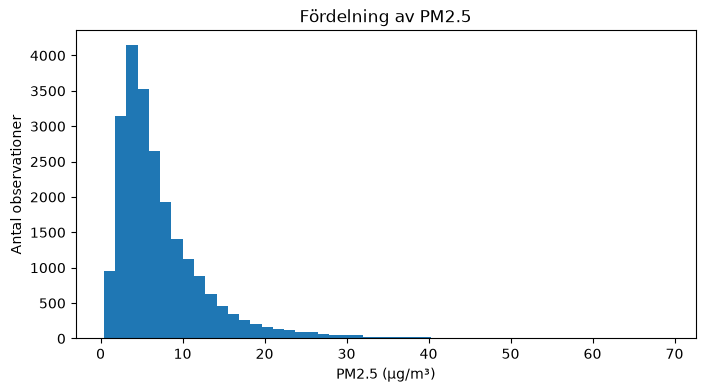

In [69]:
# Outliers
q1 = air_df["pm25"].quantile(0.25)
q3 = air_df["pm25"].quantile(0.75)

iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

print("\nNedre gräns:", round(lower_limit, 2))
print("Övre gräns:", round(upper_limit, 2))

outliers = air_df[
    (air_df["pm25"] < lower_limit) |
    (air_df["pm25"] > upper_limit)
]

print("Antal statistiska outliers:", len(outliers))

plt.figure(figsize=(8, 4))
plt.hist(air_df["pm25"].dropna(), bins=50)

plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Antal observationer")
plt.title("Fördelning av PM2.5")

plt.show()

## 7. Sammanfattning av datakvalitet och föreslagna åtgärder

Datakvalitetsanalysen visar att både PM2.5- och väderdatan innehåller
avvikelser som behöver hanteras innan data används för modellering.

**Datatyper**  
- Tidsvariabeln `tid` läses in från CSV som `str` och behöver konverteras
  till timezone-aware `datetime` (`Europe/Stockholm`) innan tidsserieanalys
  och modellering.
- Konverteringen görs i denna notebook för analysen, men bör i den slutliga
  datapipelinen hanteras vid inläsning av data.

**Luftdata (PM2.5)**  
- 31 dubbla tidsstämplar har identifierats vid månadsskiften. Dessa verkar
  uppstå i samband med den månadsvisa datahämtningen och bör i första hand
  hanteras i hämtningen av PM2.5-data.
- De två första timmarna i träningsperioden saknas.
- En tidsstämpel ligger utanför den definierade träningsperioden.
- 153 PM2.5-värden saknas vid befintliga tidsstämplar.
- Inga uppenbart orimliga mätvärden har identifierats. Fördelningen är
  tydligt högerskev, men höga PM2.5-värden bedöms kunna representera
  verkliga föroreningsepisoder och bör därför inte tas bort enbart för
  att de är statistiska extremvärden.

**Väderdata**  
- 535 förväntade tidsstämplar saknas.
- Luckorna är ojämnt fördelade och inkluderar både en längre sammanhängande
  period och perioder med varierande datatillgänglighet mellan
  väderparametrarna.
- Saknade värden förekommer även vid tidsstämplar som finns i datasetet,
  framför allt för nederbörd.
- Inga uppenbart orimliga numeriska värden har identifierats.

**Merged data**  
- Den sammanslagna datan innehåller samtliga förväntade tidsstämplar eftersom
  en tidsstämpel behålls när den förekommer i minst en av datakällorna.
- Luckor i respektive datakälla representeras därför som saknade värden
  (`NaN`) i den sammanslagna datan.

### Föreslagna åtgärder

Datatypen för `tid` bör hanteras konsekvent i datapipelinen så att variabeln
konverteras till timezone-aware `datetime` redan vid inläsning.

Problem som verkar uppstå i själva datahämtningen, exempelvis dubbla
PM2.5-observationer vid månadsskiften och observationer utanför det
efterfrågade tidsintervallet, bör i första hand korrigeras där.

Saknade observationer och värden som finns i källdatan behöver hanteras i
preprocessing. Metod bör väljas utifrån vilken variabel som saknas samt
luckornas längd och struktur. Längre sammanhängande luckor bör inte
automatiskt interpoleras.

Efter korrigering av datahämtningen bör datakvalitetskontrollerna köras
igen innan den slutliga träningsdatan skapas.